# __Importing Libraries__

In [1]:
import matplotlib.pyplot as plt
from google.colab import drive
import geopandas as gpd
import rasterio
import glob
import os

# __Installing Required Libraries__

In [2]:
! pip install geetiles
! pip install folium
! pip install matplotlib
! pip install mapclassify
! pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.3/740.3 kB 46.0 MB/s eta 0:00:00
  Created wheel for geetiles: filename=geetiles-0.1.7-py3-none-any.whl size=5411121 sha256=597ff15660b1eef1121172f4db2e48cf2d281b468fb3d894b8a2eb508dbecf6d
  Stored in directory: /root/.cache/pip/wheels/de/c3/f6/81b60cfe7bbe7f1d95005753ba865acb17bda71ba9f77930b1
Successfully built geetiles
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

# __Cloning repositories to access .wkt files__

In [2]:
! git clone https://github.com/juanmafdez/LLP_APP_Colombia

Cloning into 'LLP_APP_Colombia'...
remote: Enumerating objects: 266, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (227/227), done.
remote: Total 266 (delta 100), reused 116 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (266/266), 2.25 MiB | 7.09 MiB/s, done.
Resolving deltas: 100% (100/100), done.


# __Information Extraction__

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
# dept = 'quindio'
# dept_abrev = dept[0:3]
# gjson_file = 'gjson_data'
dept = 'tolima'
dept_abrev = dept[0:3]
gjson_file = 'gjson_data2'

In [49]:
! mkdir {gjson_file}

In [50]:
! geet grid --aoi_wkt_file LLP_APP_Colombia/deptdata/wkt/{dept}.wkt --chip_size_meters 1000 --aoi_name {dept_abrev} --dest_dir {gjson_file}

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

making grid
inspecting 45312 chips
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  12 ta

In [51]:
ee_project = 'ee-juanmafer12'
partitions_gjson = glob.glob(f"{gjson_file}/*.geojson")[0]

In [8]:
! earthengine authenticate --force

E0000 00:00:1771279335.837218    5544 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771279335.848037    5544 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771279335.879886    5544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771279335.879953    5544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771279335.879961    5544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771279335.879969    5544 computation_placer.cc:177] computation placer already registered. Please check linka

In [52]:
! geet download --tiles_file {partitions_gjson}  --dataset_def esaworldcover-2020 --pixels_lonlat [100,100] --skip_if_exists --project {ee_project}

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

downloading tiles from GEE

using the following download specficication

tiles_file:        gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
dataset_def        esaworldcover-2020
pixels_lonlat      [100, 100]
meters_per_pixel   None
max_downloads      None
shuffle            False
skip_if_exists     True
dtype              uint8
ee_auth_mode       None
n_processes        10


        
confirm (y/N): y
authenticating to Google Earth Engine
trying to use default gee credentials
-----------------------------------------------
dataset name is 'esaworldcover-2020'
-----------------------------------------------
loading chip definitions ... done
saving tiles to gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020
downloading 23902 tiles. showing progress of 10 parallel download jobs.
0 4302 5497 191

In [53]:
data_path = os.path.splitext(partitions_gjson)[0]

In [54]:
! zip -r {data_path}.zip {data_path}

Se truncaron las últimas líneas 5000 del resultado de transmisión.
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/2a5d33a562771.tif (deflated 88%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/33f6d5fa31034.tif (deflated 96%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/1bf507a193df7.tif (deflated 87%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/155c45b86adb5.tif (deflated 90%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/2ca2b09de8fc4.tif (deflated 87%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/2effe74699ca2.tif (deflated 91%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/1113ed9a01916.tif (deflated 95%)
  adding: gjson_data2/tol_partitions_aschips_2c14c05f234fb/esaworldcover-2020/0bfc4499bcc1e.tif (deflated 92%)
  adding: gjson_data2/tol_partitions_aschips_

In [55]:
! cp -r {data_path}.zip /content/drive/MyDrive/llp_col_project/datasets/esawc/{dept}

# __Label Proportions__

In [56]:
! geet select --orig_shapefile /content/LLP_APP_Colombia/deptdata/shp/{dept}/{dept}_mpios.shp --aoi_wkt_file LLP_APP_Colombia/deptdata/wkt/{dept}.wkt --tiles_name municipalities --aoi_name {dept_abrev} --dest_dir {gjson_file}

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

selecting partitions
reading orig shapefile
selecting geometries
100% (93 of 93) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

saved to gjson_data2/tol_partitions_municipalities_1cc16064e0457.geojson


In [57]:
! geet split --tiles_file {partitions_gjson} --nbands 10 --train_pct .5 --test_pct 0.3 --val_pct 0.2  --angle -1.5

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

splitting bands
saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
all splits saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb_splits.csv


In [58]:
partitions_m_gjson = glob.glob(f"{gjson_file}/*municipalities*.geojson")[0]

In [59]:
!geet intersect --tiles_file {partitions_gjson} --foreign_tiles_file {partitions_m_gjson}

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

computing intersections with foreign tiles
loading primary tiles from gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
loading foreign tiles from gjson_data2/tol_partitions_municipalities_1cc16064e0457.geojson
intersecting geometries with foreign tiles
using foreign partition name 'municipalities'
100% (23902 of 23902) |##################| Elapsed Time: 0:00:38 Time:  0:00:38
saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
done!


In [60]:
! geet split --tiles_file {partitions_gjson} --nbands 8 --train_pct .5 --test_pct 0.3 --val_pct 0.2  --angle 0.785 --foreign_tiles_name municipalities

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

splitting bands
saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
all splits saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb_splits.csv


In [61]:
! geet lp.compute --tiles_file {partitions_gjson} --labels_dataset_def esaworldcover-2020

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

computing proportions
loading tiles from gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
computing proportions for 23902 partitions
100% (23902 of 23902) |##################| Elapsed Time: 0:00:54 Time:  0:00:54

saved to gjson_data2/tol_partitions_aschips_2c14c05f234fb.geojson
done!


In [62]:
! geet download --tiles_file {partitions_m_gjson}  --dataset_def esa-world-cover  --meters_per_pixel 20  --skip_if_exists --project {ee_project}

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

downloading tiles from GEE

using the following download specficication

tiles_file:        gjson_data2/tol_partitions_municipalities_1cc16064e0457.geojson
dataset_def        esa-world-cover
pixels_lonlat      None
meters_per_pixel   20
max_downloads      None
shuffle            False
skip_if_exists     True
dtype              uint8
ee_auth_mode       None
n_processes        10


        
confirm (y/N): y
authenticating to Google Earth Engine
trying to use default gee credentials
-----------------------------------------------
dataset name is 'esa-world-cover'
-----------------------------------------------
loading chip definitions ... done
saving tiles to gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover
downloading 47 tiles. showing progress of 10 parallel download jobs.
0 2 8 14 4 12 1 10 3 

In [63]:
! geet lp.compute --tiles_file {partitions_m_gjson} --labels_dataset_def esa-world-cover

-----------------------------------------------------------
Google Earth Engine dataset extractor utility 0.1.7
-----------------------------------------------------------

computing proportions
loading tiles from gjson_data2/tol_partitions_municipalities_1cc16064e0457.geojson
computing proportions for 47 partitions
100% (47 of 47) |########################| Elapsed Time: 0:00:06 Time:  0:00:06

saved to gjson_data2/tol_partitions_municipalities_1cc16064e0457.geojson
done!


In [64]:
data_path_m = os.path.splitext(partitions_m_gjson)[0]

In [65]:
! zip -r {data_path_m}.zip {data_path_m}

  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/ (stored 0%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover.dataset_def.py (stored 0%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/ (stored 0%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/06cce9d5c174c.tif (deflated 96%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/1b5b2e4e0e03f.tif (deflated 96%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/01f448a33969d.tif (deflated 94%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/2c9782239f469.tif (deflated 93%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/1a10ecac5d1ce.tif (deflated 94%)
  adding: gjson_data2/tol_partitions_municipalities_1cc16064e0457/esa-world-cover/371cf426c8f64.tif (deflated 95%)
  adding: gjson_data2/tol_p

In [66]:
! cp -r {data_path_m}.zip /content/drive/MyDrive/llp_col_project/datasets/esawc/{dept}

In [33]:
splits_csv = glob.glob(f"{gjson_file}/*.csv")[0]

In [67]:
! cp -r {partitions_gjson} /content/drive/MyDrive/llp_col_project/datasets/esawc/{dept}
! cp -r {splits_csv} /content/drive/MyDrive/llp_col_project/datasets/esawc/{dept}
! cp -r {partitions_m_gjson} /content/drive/MyDrive/llp_col_project/datasets/esawc/{dept}

# __Visual__

In [68]:
gdf = gpd.read_file(partitions_gjson)

In [69]:
gdf.iloc[0,5]

{'2': 0.002, '3': 0.9522, '6': 0.0458}

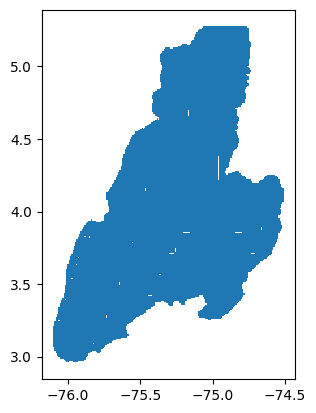

In [70]:
gdf.plot()
plt.show()

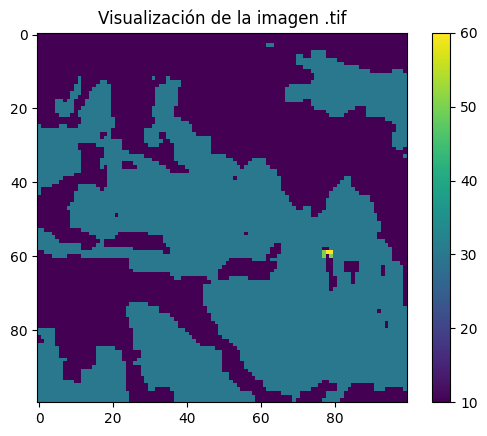

In [71]:
ruta_archivo = '/content/gjson_data/qui_partitions_aschips_13b98a63e407f/esaworldcover-2020/0002c014ae7ef.tif'
with rasterio.open(ruta_archivo) as src:
    imagen = src.read(1)

plt.imshow(imagen, cmap='viridis')
plt.colorbar()
plt.title("Visualización de la imagen .tif")
plt.show()

In [72]:
with rasterio.open(ruta_archivo) as src:
    banda1 = src.read(1)
    print(banda1)

[[10 10 10 ... 10 10 10]
 [10 10 10 ... 10 10 10]
 [10 10 10 ... 10 10 10]
 ...
 [30 30 30 ... 10 10 10]
 [30 30 30 ... 10 10 10]
 [30 30 30 ... 10 10 10]]


In [73]:
  #'#006400', // 10 - Árboles
  #'#ffbb22', // 20 - Arbustos
  #'#ffff4c', // 30 - Herbazal
  #'#f096ff', // 40 - Cultivos de secano
  #'#fa0000', // 50 - Cultivos de regadío
  #'#b4b4b4', // 60 - Suelo desnudo
  #'#0064c8', // 70 - Humedales herbáceos
  #'#0096a0', // 80 - Musgos y líquenes
  #'#00ffff', // 90 - Agua
  #'#ffffff', // 95 - Hielo y nieve
  #'#fae6a0', // 100 - Construcciones
  #'#00a000', // 110 - Manglares
  #'#a0fae6', // 120 - Pantanos inundados
  #'#70a000'  // 130 - Bosques inundados